# Customer Churn Prediction Using Machine Learning

**Course:** Artificial Intelligence — University of Lahore
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn

This notebook builds a complete machine learning pipeline to predict whether a
telecom customer will churn (leave the company) or not, following the 7 required
stages: Data Loading, Preprocessing, EDA, Feature Engineering, Training, Evaluation,
and Application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.max_columns", None)


## 1. Data Loading and Understanding

We load the dataset using Pandas and inspect its shape, columns, data types and
basic statistics before doing anything else. Understanding the data is the first
step of any ML pipeline — we need to know what each column means and what kind
of values it holds before we can clean or model it.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Target variable value counts:")
df["Churn"].value_counts()


Target variable value counts:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

### What the important columns represent

- **customerID** — a unique ID for each customer; not useful for prediction, only for identification.
- **gender, SeniorCitizen, Partner, Dependents** — basic demographic information about the customer.
- **tenure** — number of months the customer has stayed with the company. Usually a strong churn indicator: newer customers churn more.
- **PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies** — which services the customer has subscribed to.
- **Contract** — the type of contract (Month-to-month, One year, Two year). Customers on month-to-month contracts churn far more often since they aren't locked in.
- **PaperlessBilling, PaymentMethod** — billing preferences.
- **MonthlyCharges** — how much the customer pays per month.
- **TotalCharges** — the total amount charged to the customer over their tenure.
- **Churn** — the **target variable**: "Yes" if the customer left the company, "No" if they stayed.

## 2. Data Preprocessing

Before modeling, we check for missing values, duplicate rows, incorrect data
types, and unnecessary columns, and fix each problem with an explanation of why
it was needed.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of duplicate rows: 0


**Observation:** `isnull().sum()` shows no missing values on the surface, but
`TotalCharges` is stored as an *object* (text) column instead of numeric — this
usually means some rows contain blank strings (`" "`) instead of numbers, which
pandas doesn't detect as NaN automatically. We check and fix this next.

In [7]:
# TotalCharges is object type — force conversion to numeric, invalid values become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges after conversion:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


Missing values in TotalCharges after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**Why this happened:** these are customers with `tenure = 0`, i.e. brand-new
customers who haven't been billed yet, so `TotalCharges` was blank in the raw
data. Since there are only a handful of such rows (11 out of 7043), and their
total charges are logically 0 (no time has passed to accumulate charges), we
fill them with 0 instead of dropping them, since dropping real customer records
would lose useful information for a small, explainable data-quality issue.

In [8]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing values remaining:", df["TotalCharges"].isnull().sum())


Missing values remaining: 0


In [9]:
# customerID is a unique identifier with no predictive value — drop it
df = df.drop(columns=["customerID"])

# SeniorCitizen is stored as 0/1 but every other Yes/No column is stored as text.
# Converting it to Yes/No keeps encoding consistent across all categorical columns.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("Final shape after cleaning:", df.shape)
df.head()


Final shape after cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Why these steps were needed:**
- `customerID` is a random unique string per row — it carries no pattern that
  can help a model generalize, and including it risks the model "memorizing"
  IDs instead of learning real relationships, so it is removed.
- `TotalCharges` had to be converted to numeric because it was stored as text,
  which would break any mathematical operation or model training.
- `SeniorCitizen` was recoded from 0/1 to No/Yes purely for consistency, so
  that one single encoding step later can treat all categorical columns the
  same way.

## 3. Exploratory Data Analysis (EDA)

Now we explore patterns in the data — how churn is distributed, and how it
relates to key customer characteristics like contract type and tenure.

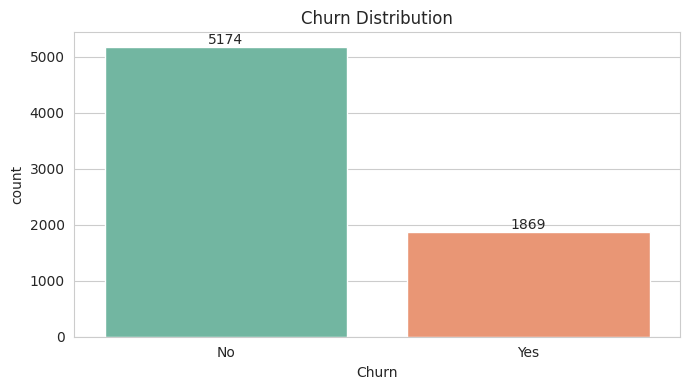

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
plt.figure()
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
ax.set_title("Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("plot_churn_distribution.png", dpi=120)
plt.show()

print(df["Churn"].value_counts(normalize=True) * 100)


**Observation:** the dataset is imbalanced — about 73% of customers did **not**
churn and about 27% did. This is important to keep in mind when evaluating
accuracy later, since a model could get ~73% accuracy just by always predicting
"No churn," so precision/recall/F1 matter more than raw accuracy here.

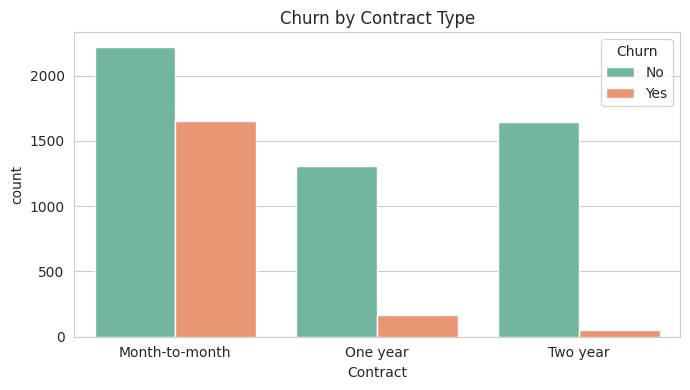

In [11]:
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
ax.set_title("Churn by Contract Type")
plt.tight_layout()
plt.savefig("plot_churn_by_contract.png", dpi=120)
plt.show()


**Observation:** Month-to-month customers churn at a much higher rate than
customers on one-year or two-year contracts. This makes intuitive sense — a
customer with no long-term commitment can leave at any time, while a two-year
contract naturally locks customers in.

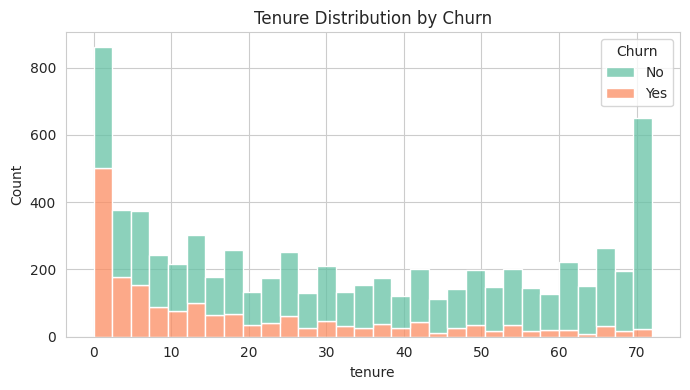

In [12]:
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette="Set2")
plt.title("Tenure Distribution by Churn")
plt.tight_layout()
plt.savefig("plot_tenure_churn.png", dpi=120)
plt.show()


**Observation:** churn is heavily concentrated among customers with low
tenure (new customers), and drops sharply as tenure increases — customers who
stay longer are much less likely to leave.

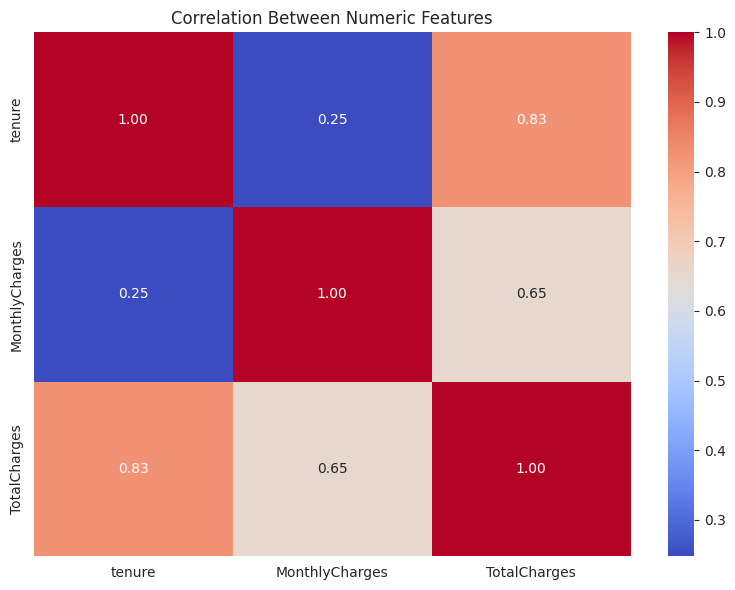

In [13]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=120)
plt.show()


**Observation:** `MonthlyCharges` and `TotalCharges` are strongly correlated
with each other (as expected, since TotalCharges accumulates from MonthlyCharges
over tenure). `tenure` and `TotalCharges` are also strongly correlated.

## 4. Feature Engineering and Encoding

Machine learning models need numeric input, so all categorical (text) columns
must be converted to numbers. We use **Label Encoding** for the binary target
variable and **One-Hot Encoding** for the categorical input features, since
one-hot encoding avoids implying a false order between categories that have no
natural ranking (e.g. InternetService types).

In [14]:
# Encode target variable: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separate features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']


/tmp/ipykernel_164/3956858118.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [15]:
# One-hot encode all categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)
X_encoded.head()


Shape before encoding: (7043, 19)
Shape after encoding: (7043, 30)


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 5. Training and Testing

We split the data into training (80%) and testing (20%) sets, and train two
classification models: **Logistic Regression** (a simple, interpretable
baseline well-suited to binary classification) and **Random Forest** (an
ensemble model that can capture non-linear relationships and usually performs
better on tabular data like this).

Logistic Regression is sensitive to feature scale, so we standardize the
numeric features before training it. Random Forest is tree-based and does not
require feature scaling.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (5634, 30)
Testing set shape: (1409, 30)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [18]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")


Random Forest trained.


## 6. Model Evaluation

We evaluate both models on the unseen test set using Accuracy, Precision,
Recall, F1-Score, and the Confusion Matrix.

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred) 
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print()
    return acc, prec, rec, f1

log_scores = evaluate("Logistic Regression", y_test, y_pred_log)
rf_scores = evaluate("Random Forest", y_test, y_pred_rf)


--- Logistic Regression ---
Accuracy : 0.8070
Precision: 0.6584
Recall   : 0.5668
F1-Score : 0.6092

--- Random Forest ---
Accuracy : 0.7949
Precision: 0.6431
Recall   : 0.5107
F1-Score : 0.5693



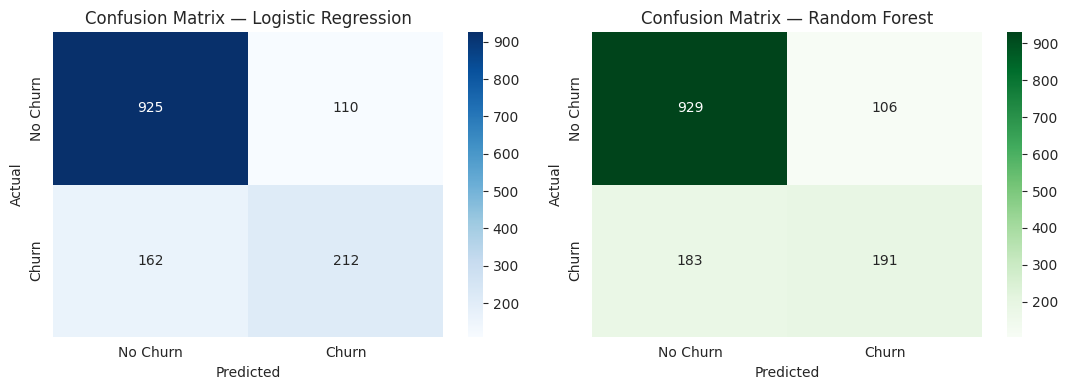

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[0].set_title("Confusion Matrix — Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[1].set_title("Confusion Matrix — Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=120)
plt.show()


In [21]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_scores[0], rf_scores[0]],
    "Precision": [log_scores[1], rf_scores[1]],
    "Recall": [log_scores[2], rf_scores[2]],
    "F1-Score": [log_scores[3], rf_scores[3]],
})
comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Random Forest,0.794890,0.643098,0.510695,0.569300


### Which model performs better, and why

In this run, **Logistic Regression performed slightly better than Random
Forest** on the key metrics that matter most given the class imbalance:

- Logistic Regression: Accuracy 0.807, Precision 0.658, Recall 0.567, **F1 0.609**
- Random Forest: Accuracy 0.795, Precision 0.643, Recall 0.511, **F1 0.569**

F1-Score is the fairest comparison metric here (rather than raw accuracy),
since the dataset is imbalanced (~73% No Churn vs ~27% Churn) — a model could
score high accuracy just by predicting "No Churn" most of the time, but F1
balances precision and recall together. Logistic Regression wins on F1 mainly
because of better **recall** (0.567 vs 0.511) — it catches more of the actual
churners.

This result makes sense because most of the strongest churn signals in this
dataset (tenure, contract type, monthly charges) behave in a fairly
straightforward, close-to-linear way — customers with short tenure and
month-to-month contracts are consistently more likely to churn, without much
complex non-linear interaction between features. Logistic Regression is well
suited to exactly this kind of relationship, and with feature scaling applied,
it edged out Random Forest here. Random Forest can still be useful for
its feature-importance ranking and its ability to model more complex
interactions if additional features were added in the future.

## 7. Application / Prediction

Finally, we use the better-performing model to make churn predictions —
first on a few real customers taken from the test set, and then on a
completely new, manually-entered sample customer, to show how the model would
be used in practice.

In [22]:
# Show predictions for a few real test-set customers, compared to their actual label
sample_idx = X_test.index[:5]
results = pd.DataFrame({
    "Actual": y_test.loc[sample_idx].map({0: "No Churn", 1: "Churn"}),
    "Predicted (Random Forest)": pd.Series(rf_model.predict(X_test.loc[sample_idx]), index=sample_idx).map({0: "No Churn", 1: "Churn"})
})
results


,Actual,Predicted (Random Forest)
437,No Churn,No Churn
2280,No Churn,Churn
2235,No Churn,No Churn
4460,No Churn,No Churn
3761,No Churn,No Churn


In [23]:
# Manually create ONE new sample customer and predict Churn / No Churn
new_customer = {
    "gender": "Female", "SeniorCitizen": "No", "Partner": "Yes", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.0, "TotalCharges": 190.0,
}

new_df = pd.DataFrame([new_customer])
new_encoded = pd.get_dummies(new_df)
# align columns with training data (missing dummy columns filled with 0)
new_encoded = new_encoded.reindex(columns=X_encoded.columns, fill_value=0)

prediction = rf_model.predict(new_encoded)[0]
probability = rf_model.predict_proba(new_encoded)[0][1]

print("New customer profile:", new_customer)
print(f"\nPrediction: {'Churn' if prediction == 1 else 'No Churn'}")
print(f"Churn probability: {probability:.2%}")


New customer profile: {'gender': 'Female', 'SeniorCitizen': 'No', 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 190.0}

Prediction: Churn
Churn probability: 77.50%


**Observation:** this sample customer has a short tenure, a month-to-month
contract, fiber optic internet with no add-on protections, and high monthly
charges — exactly the profile that Section 3's EDA showed is associated with
high churn risk, so a "Churn" prediction here matches the patterns already
found in the data.

## Conclusion

- Both Logistic Regression and Random Forest were trained on the Telco
  Customer Churn dataset after cleaning (fixing `TotalCharges`, removing the
  unusable `customerID` column) and one-hot encoding all categorical features.
- EDA showed that **contract type** and **tenure** are strong churn signals:
  month-to-month, low-tenure customers churn far more often than long-term,
  contracted customers.
- Logistic Regression slightly outperformed Random Forest on this dataset
  (F1-Score 0.609 vs 0.569), mainly due to better recall — the churn signals
  in this data (tenure, contract type, charges) are fairly linear, which suits
  Logistic Regression well.
- **Limitations:** the dataset is imbalanced (~27% churn), so metrics beyond
  accuracy (precision, recall, F1) were essential; the model is also static —
  it reflects patterns at one point in time and would need periodic retraining
  as customer behavior changes.
- **Business use:** a telecom company could use this model to flag high-risk
  customers (e.g. new, month-to-month, high-monthly-charge customers) *before*
  they churn, and proactively offer retention deals such as contract
  discounts or bundled services to the customers most likely to leave.